# Classification unimodale des textes

Ce notebook est dedie a la classification multi-label basee uniquement sur les descriptions textuelles (`Caption`) du projet BIHAR 2025.

Objectif principal : produire un modele texte unimodal de reference. Le meilleur modele texte pourra ensuite etre sauvegarde dans `model/registry/` et reutilise comme branche textuelle dans le notebook de fusion multimodale.

Objectifs du notebook :
- preparer les donnees textuelles,
- construire des baselines de Machine Learning,
- experimenter des modeles Deep Learning pour le texte,
- comparer les resultats avec des metriques adaptees au multi-label,
- interpreter les predictions et analyser les erreurs,
- selectionner le meilleur modele texte pour la fusion multimodale.


## Plan du notebook

1. Description synthetique du projet et des objectifs.
2. Chargement des donnees et verification des colonnes utiles.
3. Analyse exploratoire des captions et des labels.
4. Separation commune train / validation / test en 70% / 15% / 15%.
5. Pretraitement NLP : nettoyage, stopwords, lemmatisation et tokenisation.
6. Representations textuelles : TF-IDF, sequences tokenisees et embeddings pre-entraines.
7. Baselines Machine Learning : Logistic Regression et SVM en One-vs-Rest.
8. Modeles Deep Learning texte : LSTM, BiLSTM, CNN1D et architecture hybride.
9. Evaluation multi-label : F1 micro/macro, Average Precision, AUC et matrice de confusion multilabel.
10. Analyse qualitative des predictions et interpretation avec LimeTextExplainer.
11. Selection et sauvegarde du meilleur modele texte pour la fusion multimodale.


## 1. Description synthetique du projet et des objectifs

Dans ce notebook, on traite uniquement la modalite texte du probleme multimodal. Le but est de predire un ou plusieurs labels a partir de la description textuelle associee a chaque image.

La caption est l'entree du modele, tandis que les labels restent la cible supervisee. Les pixels des images ne sont pas utilises dans cette partie afin de mesurer la performance de la modalite texte seule.

Points attendus :
- classification multi-label,
- pretraitement NLP explicite,
- comparaison entre approches classiques et deep learning,
- evaluation avec des metriques adaptees,
- interpretation des resultats obtenus,
- sauvegarde du modele texte retenu pour la fusion multimodale.


## 2. Chargement des donnees

Cette partie doit charger :
- le fichier `train.csv`,
- les librairies necessaires a la partie texte,
- les colonnes utiles : `ImageID`, `Caption`, `Labels`.


In [254]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

In [255]:


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import common

print("Racine du projet :", PROJECT_ROOT)
print("Fichier train.csv :", common.TRAIN_CSV_PATH)
print("train.csv existe :", common.TRAIN_CSV_PATH.exists())

Racine du projet : c:\Users\mupps\Documents\Tp_bihar-2025-2026
Fichier train.csv : C:\Users\mupps\Documents\Tp_bihar-2025-2026\train.csv
train.csv existe : True


In [256]:
try:
    df = pd.read_csv(common.TRAIN_CSV_PATH)
    print("Lecture normale du CSV OK")
except pd.errors.ParserError:
    df = pd.read_csv(
        common.TRAIN_CSV_PATH,
        engine="python",
        on_bad_lines="skip",
    )
    print("Lecture avec engine='python' et on_bad_lines='skip'")

print("Shape du dataset :", df.shape)
display(df.head())



Lecture avec engine='python' et on_bad_lines='skip'
Shape du dataset : (29918, 3)


,ImageID,Labels,Caption
0,0.jpg,1,Woman in swim suit holding parasol on sunny day.
1,1.jpg,1 19,A couple of men riding horses on top of a gree...
2,2.jpg,1,They are brave for riding in the jungle on tho...
3,3.jpg,8 3 13,a black and silver clock tower at an intersect...
4,4.jpg,8 3 7,A train coming to a stop on the tracks out side.


In [257]:
expected_columns = {"ImageID", "Caption", "Labels"}
missing_columns = expected_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Colonnes manquantes : {missing_columns}")

df = df[["ImageID", "Caption", "Labels"]].copy()

df["ImageID"] = df["ImageID"].astype(str).str.strip()
df["Caption"] = df["Caption"].astype(str).str.strip()
df["Labels"] = df["Labels"].astype(str).str.strip()

df = df[
    (df["ImageID"] != "") &
    (df["Caption"] != "") &
    (df["Labels"] != "")
].copy()

print("Shape apres filtrage :", df.shape)
display(df.head())

Shape apres filtrage : (29918, 3)


,ImageID,Caption,Labels
0,0.jpg,Woman in swim suit holding parasol on sunny day.,1
1,1.jpg,A couple of men riding horses on top of a gree...,1 19
2,2.jpg,They are brave for riding in the jungle on tho...,1
3,3.jpg,a black and silver clock tower at an intersect...,8 3 13
4,4.jpg,A train coming to a stop on the tracks out side.,8 3 7


In [258]:
def parse_labels(label_string):
    return [int(label) for label in str(label_string).split()]


df["Labels_list"] = df["Labels"].apply(parse_labels)

display(df[["ImageID", "Caption", "Labels", "Labels_list"]].head())

,ImageID,Caption,Labels,Labels_list
0,0.jpg,Woman in swim suit holding parasol on sunny day.,1,[1]
1,1.jpg,A couple of men riding horses on top of a gree...,1 19,"[1, 19]"
2,2.jpg,They are brave for riding in the jungle on tho...,1,[1]
3,3.jpg,a black and silver clock tower at an intersect...,8 3 13,"[8, 3, 13]"
4,4.jpg,A train coming to a stop on the tracks out side.,8 3 7,"[8, 3, 7]"


In [259]:
print("Nombre total d'exemples :", len(df))
print("Nombre de captions manquantes :", df["Caption"].isna().sum())
print("Nombre de labels manquants :", df["Labels"].isna().sum())
print("Nombre de doublons ImageID :", df["ImageID"].duplicated().sum())

all_labels = sorted({label for labels in df["Labels_list"] for label in labels})

print("Labels uniques :", all_labels)
print("Nombre de labels uniques :", len(all_labels))

Nombre total d'exemples : 29918
Nombre de captions manquantes : 0
Nombre de labels manquants : 0
Nombre de doublons ImageID : 0
Labels uniques : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
Nombre de labels uniques : 18


## 3. Analyse exploratoire des donnees

Objectifs :
- verifier la taille du dataset,
- detecter des valeurs manquantes,
- observer les captions,
- etudier les longueurs des textes,
- analyser la distribution des labels.


### 3.1 Vue generale du dataset


In [260]:
print("Nombre total d'exemples :", len(df))
print("Nombre de colonnes :", df.shape[1])

display(df.head())
display(df.info())

Nombre total d'exemples : 29918
Nombre de colonnes : 4


,ImageID,Caption,Labels,Labels_list
0,0.jpg,Woman in swim suit holding parasol on sunny day.,1,[1]
1,1.jpg,A couple of men riding horses on top of a gree...,1 19,"[1, 19]"
2,2.jpg,They are brave for riding in the jungle on tho...,1,[1]
3,3.jpg,a black and silver clock tower at an intersect...,8 3 13,"[8, 3, 13]"
4,4.jpg,A train coming to a stop on the tracks out side.,8 3 7,"[8, 3, 7]"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29918 entries, 0 to 29917
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ImageID      29918 non-null  object
 1   Caption      29918 non-null  object
 2   Labels       29918 non-null  object
 3   Labels_list  29918 non-null  object
dtypes: object(4)
memory usage: 935.1+ KB


None

In [261]:
missing_values = df.isna().sum()

print("Valeurs manquantes par colonne :")
display(missing_values)

Valeurs manquantes par colonne :


ImageID        0
Caption        0
Labels         0
Labels_list    0
dtype: int64

In [262]:
print("Nombre de doublons ImageID :", df["ImageID"].duplicated().sum())
print("Nombre de captions dupliquees :", df["Caption"].duplicated().sum())

Nombre de doublons ImageID : 0
Nombre de captions dupliquees : 764


### 3.2 Exemples de descriptions textuelles


In [263]:
sample_captions = df.sample(
    n=10,
    random_state=common.RANDOM_STATE,
)[["ImageID", "Caption", "Labels", "Labels_list"]]

display(sample_captions)

,ImageID,Caption,Labels,Labels_list
10373,10404.jpg,A man and a woman ties a boat to a wall.,9 1,"[9, 1]"
15978,16025.jpg,A black and white photo showing a pitch being ...,1,[1]
22629,22693.jpg,A plate with two different kinds of donuts.,1,[1]
3246,3257.jpg,A man sitting at a table eating pizza slices,1,[1]
18418,18472.jpg,A large red fire truck driving down a road.,8,[8]
29318,29399.jpg,A woman sitting in a chair holding her dog.,1 18,"[1, 18]"
21739,21801.jpg,Hummingbirds flutter around plants against a b...,16,[16]
18789,18843.jpg,this is a airiel view of a huge traffic jam,8 1 3 6,"[8, 1, 3, 6]"
3585,3598.jpg,A person does a trick on a board in the water.,1,[1]
13053,13092.jpg,A man in a suit and tie holding a bag walking ...,1 2,"[1, 2]"


In [264]:
for _, row in sample_captions.iterrows():
    print("ImageID :", row["ImageID"])
    print("Caption :", row["Caption"])
    print("Labels :", row["Labels_list"])
    print("---")

ImageID : 10404.jpg
Caption : A man and a woman ties a boat to a wall.
Labels : [9, 1]
---
ImageID : 16025.jpg
Caption : A black and white photo showing a pitch being thrown to a batter.
Labels : [1]
---
ImageID : 22693.jpg
Caption : A plate with two different kinds of donuts.
Labels : [1]
---
ImageID : 3257.jpg
Caption : A man sitting at a table eating pizza slices
Labels : [1]
---
ImageID : 18472.jpg
Caption : A large red fire truck driving down a road.
Labels : [8]
---
ImageID : 29399.jpg
Caption : A woman sitting in a chair holding her dog.
Labels : [1, 18]
---
ImageID : 21801.jpg
Caption : Hummingbirds flutter around plants against a bright blue sky.
Labels : [16]
---
ImageID : 18843.jpg
Caption : this is a airiel view of a huge traffic jam
Labels : [8, 1, 3, 6]
---
ImageID : 3598.jpg
Caption : A person does a trick on a board in the water.
Labels : [1]
---
ImageID : 13092.jpg
Caption : A man in a suit and tie holding a bag walking in front of a building and another man behind him

### 3.3 Analyse des longueurs de captions


In [265]:
df["caption_word_count"] = df["Caption"].apply(lambda text: len(str(text).split()))
df["caption_char_count"] = df["Caption"].apply(lambda text: len(str(text)))

display(
    df[["caption_word_count", "caption_char_count"]].describe()
)

,caption_word_count,caption_char_count
count,29918.000000,29918.000000
mean,10.482619,51.942844
std,2.222374,11.608884
min,7.000000,23.000000
25%,9.000000,44.000000
50%,10.000000,50.000000
75%,11.000000,57.000000
max,49.000000,245.000000


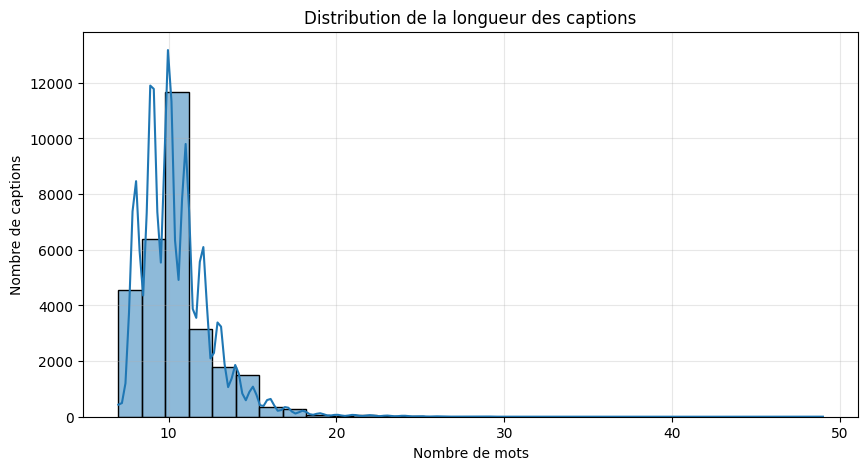

In [266]:
plt.figure(figsize=(10, 5))
sns.histplot(df["caption_word_count"], bins=30, kde=True)
plt.title("Distribution de la longueur des captions")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de captions")
plt.grid(alpha=0.3)
plt.show()

In [267]:
longest_captions = df.sort_values(
    by="caption_word_count",
    ascending=False,
).head(10)

display(longest_captions[["ImageID", "Caption", "Labels", "caption_word_count"]])

,ImageID,Caption,Labels,caption_word_count
3998,4012.jpg,"Black night, a blurry shot shows a tall fence ...",1 3,49
13541,13581.jpg,"Corner view of a table with plaid cloth, red a...",1,39
25597,25669.jpg,Densely growing trees and a low fence frame th...,18,38
26425,26502.jpg,Two women are standing in front of a window th...,1,37
13366,13406.jpg,"Several people are standing, or sitting, in th...",1 15,37
25251,25321.jpg,A man sitting cross legged on wood floor with ...,1,36
25883,25956.jpg,In front of an open doorway to a room with two...,1,33
23092,23156.jpg,A man wearing a suit with a blue tie stands ne...,1,32
26838,26916.jpg,A couple of posts and a number of signs line e...,3 13,32
7397,7418.jpg,Two men one wearing their hat backwards has hi...,1 15,31


### 3.4 Analyse des labels


In [268]:
all_labels = [label for labels in df["Labels_list"] for label in labels]
label_counts = Counter(all_labels)

unique_labels = sorted(label_counts.keys())

print("Labels uniques :", unique_labels)
print("Nombre de labels uniques :", len(unique_labels))

label_distribution = pd.DataFrame({
    "label": list(label_counts.keys()),
    "count": list(label_counts.values()),
}).sort_values("label")

label_distribution["frequency_percent"] = (
    label_distribution["count"] / len(df) * 100
).round(2)

display(label_distribution)

Labels uniques : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
Nombre de labels uniques : 18


,label,count,frequency_percent
0,1,22755,76.06
14,2,1160,3.88
3,3,4345,14.52
7,4,1271,4.25
6,5,1128,3.77
10,6,1388,4.64
5,7,1217,4.07
2,8,2203,7.36
11,9,1041,3.48
13,10,1458,4.87


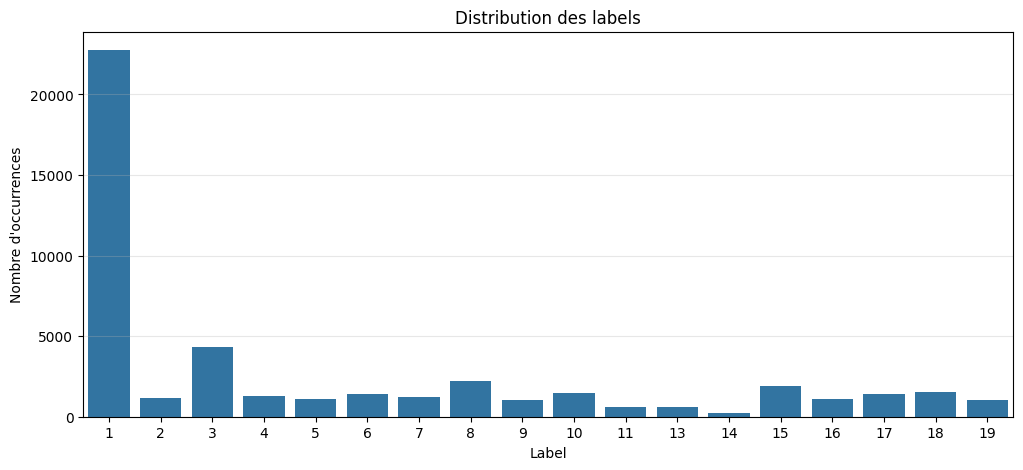

In [269]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=label_distribution,
    x="label",
    y="count",
)
plt.title("Distribution des labels")
plt.xlabel("Label")
plt.ylabel("Nombre d'occurrences")
plt.grid(axis="y", alpha=0.3)
plt.show()

count    29918.000000
mean         1.550806
std          0.902365
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          7.000000
Name: num_labels, dtype: float64

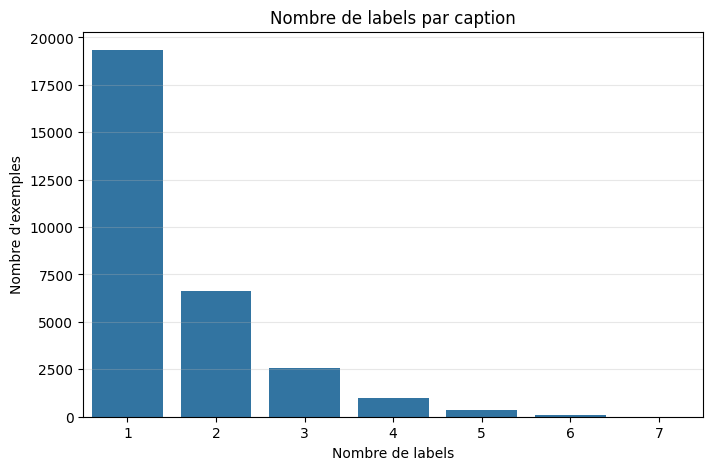

In [270]:
df["num_labels"] = df["Labels_list"].apply(len)

display(df["num_labels"].describe())

plt.figure(figsize=(8, 5))
sns.countplot(x=df["num_labels"])
plt.title("Nombre de labels par caption")
plt.xlabel("Nombre de labels")
plt.ylabel("Nombre d'exemples")
plt.grid(axis="y", alpha=0.3)
plt.show()

### 3.5 Mots frequents et premiers patterns


In [271]:
import re
from collections import Counter

def simple_tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    return tokens


all_tokens = []

for caption in df["Caption"]:
    all_tokens.extend(simple_tokenize(caption))

word_counts = Counter(all_tokens)

most_common_words = pd.DataFrame(
    word_counts.most_common(30),
    columns=["word", "count"],
)

display(most_common_words)

,word,count
0,a,53646
1,on,11114
2,of,10668
3,the,9537
4,in,8956
5,with,6107
6,man,5539
7,and,5063
8,is,4599
9,to,3906


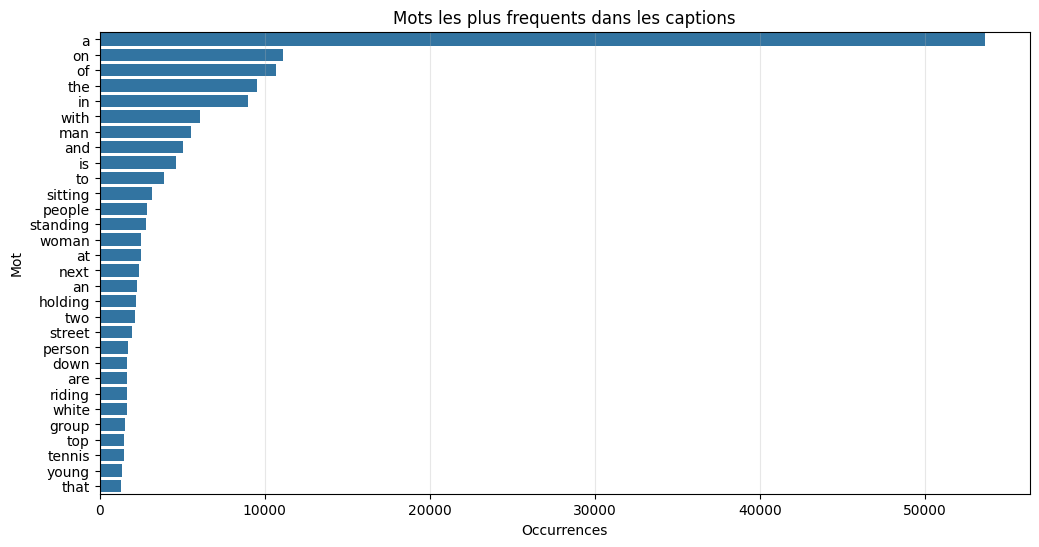

In [272]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=most_common_words,
    x="count",
    y="word",
)
plt.title("Mots les plus frequents dans les captions")
plt.xlabel("Occurrences")
plt.ylabel("Mot")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [273]:
basic_stopwords = {
    "a", "an", "the", "in", "on", "of", "and", "or", "to", "with",
    "is", "are", "at", "by", "for", "from", "this", "that", "there",
    "as", "it", "its", "be", "was", "were"
}

filtered_tokens = [
    token for token in all_tokens
    if token not in basic_stopwords and len(token) > 2
]

filtered_word_counts = Counter(filtered_tokens)

most_common_filtered_words = pd.DataFrame(
    filtered_word_counts.most_common(30),
    columns=["word", "count"],
)

display(most_common_filtered_words)

,word,count
0,man,5539
1,sitting,3160
2,people,2848
3,standing,2822
4,woman,2534
5,next,2376
6,holding,2209
7,two,2162
8,street,1987
9,person,1731


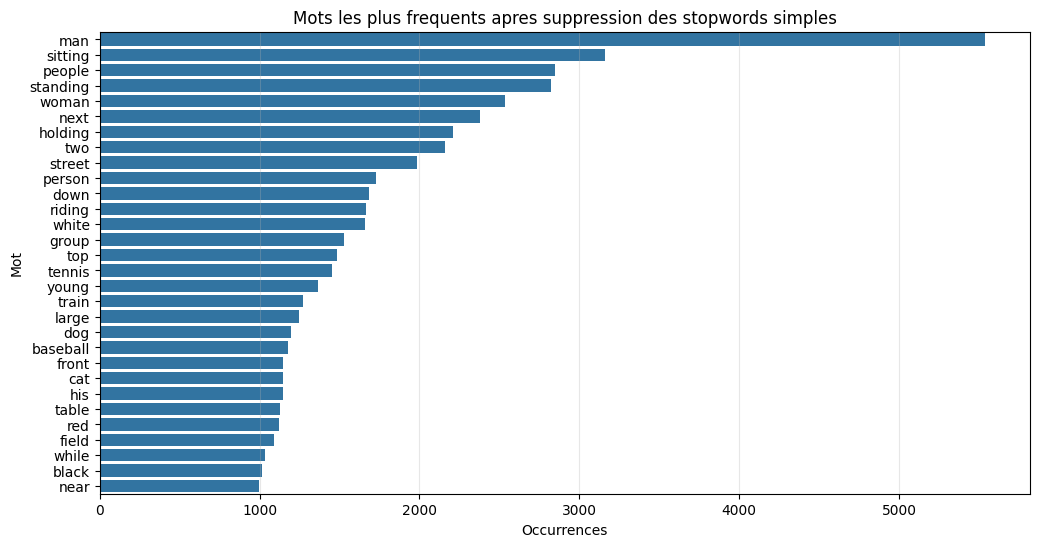

In [274]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=most_common_filtered_words,
    x="count",
    y="word",
)
plt.title("Mots les plus frequents apres suppression des stopwords simples")
plt.xlabel("Occurrences")
plt.ylabel("Mot")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [275]:
for label in unique_labels:
    label_captions = df[
        df["Labels_list"].apply(lambda labels: label in labels)
    ]["Caption"]

    label_tokens = []

    for caption in label_captions:
        label_tokens.extend(simple_tokenize(caption))

    label_tokens = [
        token for token in label_tokens
        if token not in basic_stopwords and len(token) > 2
    ]

    label_word_counts = Counter(label_tokens)

    print(f"Label {label} - mots frequents :")
    print(label_word_counts.most_common(10))
    print("---")

Label 1 - mots frequents :
[('man', 5525), ('people', 2837), ('woman', 2531), ('standing', 2443), ('holding', 2178), ('sitting', 2160), ('two', 1722), ('person', 1721), ('next', 1630), ('riding', 1628)]
---
Label 2 - mots frequents :
[('street', 274), ('man', 234), ('bike', 230), ('riding', 169), ('people', 167), ('bicycle', 143), ('next', 134), ('down', 130), ('parked', 118), ('woman', 97)]
---
Label 3 - mots frequents :
[('street', 1142), ('man', 530), ('down', 440), ('bus', 429), ('people', 426), ('next', 394), ('city', 383), ('car', 381), ('sitting', 359), ('parked', 327)]
---
Label 4 - mots frequents :
[('motorcycle', 527), ('parked', 258), ('man', 240), ('street', 240), ('riding', 223), ('motorcycles', 187), ('people', 144), ('next', 131), ('down', 126), ('sitting', 124)]
---
Label 5 - mots frequents :
[('airplane', 378), ('plane', 341), ('flying', 273), ('large', 224), ('sky', 202), ('airport', 200), ('runway', 196), ('jet', 188), ('sitting', 171), ('air', 127)]
---
Label 6 - mo

## 4. Separation des donnees en train / validation / test

Le projet demande une separation 70% / 15% / 15% a partir du fichier `train.csv` annote.


In [276]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer



In [277]:
X = df[["ImageID", "Caption", "Labels", "Labels_list"]].copy()

print("Nombre total d'exemples :", len(X))
display(X.head())

Nombre total d'exemples : 29918


,ImageID,Caption,Labels,Labels_list
0,0.jpg,Woman in swim suit holding parasol on sunny day.,1,[1]
1,1.jpg,A couple of men riding horses on top of a gree...,1 19,"[1, 19]"
2,2.jpg,They are brave for riding in the jungle on tho...,1,[1]
3,3.jpg,a black and silver clock tower at an intersect...,8 3 13,"[8, 3, 13]"
4,4.jpg,A train coming to a stop on the tracks out side.,8 3 7,"[8, 3, 7]"


### 4.1 Split 70% / 15% / 15%

In [278]:
train_df, temp_df = train_test_split(
    X,
    test_size=0.30,
    random_state=common.RANDOM_STATE,
    shuffle=True,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=common.RANDOM_STATE,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train :", train_df.shape)
print("Validation :", val_df.shape)
print("Test :", test_df.shape)

print("Proportion train :", round(len(train_df) / len(X), 2))
print("Proportion validation :", round(len(val_df) / len(X), 2))
print("Proportion test :", round(len(test_df) / len(X), 2))

Train : (20942, 4)
Validation : (4488, 4)
Test : (4488, 4)
Proportion train : 0.7
Proportion validation : 0.15
Proportion test : 0.15


In [279]:
mlb = MultiLabelBinarizer()

y_train = mlb.fit_transform(train_df["Labels_list"])
y_val = mlb.transform(val_df["Labels_list"])
y_test = mlb.transform(test_df["Labels_list"])

NUM_CLASSES = len(mlb.classes_)

print("Classes :", mlb.classes_)
print("Nombre de classes :", NUM_CLASSES)

print("y_train shape :", y_train.shape)
print("y_val shape :", y_val.shape)
print("y_test shape :", y_test.shape)

Classes : [ 1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19]
Nombre de classes : 18
y_train shape : (20942, 18)
y_val shape : (4488, 18)
y_test shape : (4488, 18)


In [280]:
expected_labels = set(sorted({label for labels in df["Labels_list"] for label in labels}))
encoded_labels = set(mlb.classes_)

print("Labels attendus :", sorted(expected_labels))
print("Labels encodes :", sorted(encoded_labels))
print("Labels manquants :", expected_labels - encoded_labels)
print("Labels supplementaires :", encoded_labels - expected_labels)

Labels attendus : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
Labels encodes : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]
Labels manquants : set()
Labels supplementaires : set()


In [281]:
def label_distribution_from_binary(y_binary, classes):
    counts = y_binary.sum(axis=0)

    distribution = pd.DataFrame({
        "label": classes,
        "count": counts,
    })

    distribution["frequency_percent"] = (
        distribution["count"] / len(y_binary) * 100
    ).round(2)

    return distribution


train_label_distribution = label_distribution_from_binary(y_train, mlb.classes_)
val_label_distribution = label_distribution_from_binary(y_val, mlb.classes_)
test_label_distribution = label_distribution_from_binary(y_test, mlb.classes_)

display(train_label_distribution)
display(val_label_distribution)
display(test_label_distribution)

,label,count,frequency_percent
0,1,15920,76.02
1,2,797,3.81
2,3,3035,14.49
3,4,876,4.18
4,5,788,3.76
5,6,970,4.63
6,7,866,4.14
7,8,1544,7.37
8,9,751,3.59
9,10,1016,4.85


,label,count,frequency_percent
0,1,3393,75.60
1,2,177,3.94
2,3,646,14.39
3,4,176,3.92
4,5,182,4.06
5,6,226,5.04
6,7,171,3.81
7,8,319,7.11
8,9,148,3.30
9,10,210,4.68


,label,count,frequency_percent
0,1,3442,76.69
1,2,186,4.14
2,3,664,14.80
3,4,219,4.88
4,5,158,3.52
5,6,192,4.28
6,7,180,4.01
7,8,340,7.58
8,9,142,3.16
9,10,232,5.17


,label,train,validation,test
0,1,15920,3393,3442
1,2,797,177,186
2,3,3035,646,664
3,4,876,176,219
4,5,788,182,158
5,6,970,226,192
6,7,866,171,180
7,8,1544,319,340
8,9,751,148,142
9,10,1016,210,232


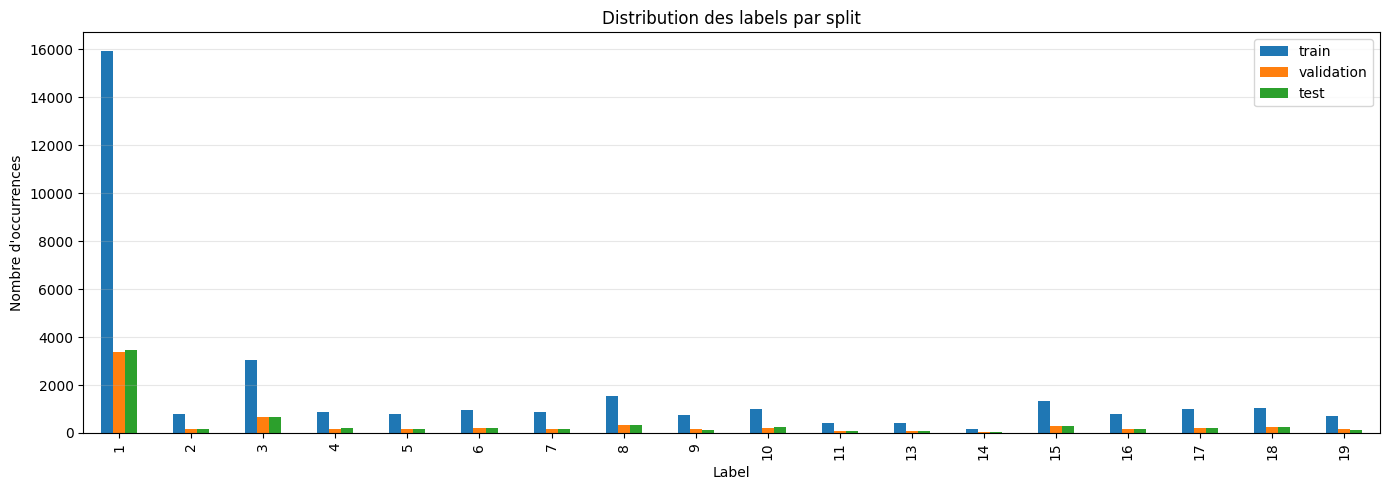

In [282]:
split_distribution = train_label_distribution[["label", "count"]].rename(
    columns={"count": "train"}
)

split_distribution["validation"] = val_label_distribution["count"].values
split_distribution["test"] = test_label_distribution["count"].values

display(split_distribution)

split_distribution.plot(
    x="label",
    y=["train", "validation", "test"],
    kind="bar",
    figsize=(14, 5),
)

plt.title("Distribution des labels par split")
plt.xlabel("Label")
plt.ylabel("Nombre d'occurrences")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Pretraitement des textes

Dans cette partie, on prepare les captions pour les modeles classiques et deep learning.


### 5.1 Nettoyage des textes


In [283]:
import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [284]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mupps\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mupps\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mupps\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [285]:
english_stopwords = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [286]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in english_stopwords and len(token) > 2
    ]

    return " ".join(tokens)

In [287]:
train_df["clean_caption"] = train_df["Caption"].apply(clean_text)
val_df["clean_caption"] = val_df["Caption"].apply(clean_text)
test_df["clean_caption"] = test_df["Caption"].apply(clean_text)

display(train_df[["Caption", "clean_caption", "Labels_list"]].head())

,Caption,clean_caption,Labels_list
0,A woman drinking from a glass while wearing gl...,woman drinking glass wearing glass,[1]
1,A cat sits on the couch next to the remote.,cat sits couch next remote,[17]
2,a man with a banana hat on,man banana hat,[1]
3,Blond lady washing her hands in a public restr...,blond lady washing hand public restroom,[1]
4,A young man washing an elephant in a river.,young man washing elephant river,[1]


In [288]:
print("Captions vides train :", (train_df["clean_caption"].str.len() == 0).sum())
print("Captions vides validation :", (val_df["clean_caption"].str.len() == 0).sum())
print("Captions vides test :", (test_df["clean_caption"].str.len() == 0).sum())

Captions vides train : 0
Captions vides validation : 0
Captions vides test : 0


### 5.2 Representation pour Machine Learning classique


In [289]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [290]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["clean_caption"])
X_val_tfidf = tfidf_vectorizer.transform(val_df["clean_caption"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["clean_caption"])

print("X_train_tfidf shape :", X_train_tfidf.shape)
print("X_val_tfidf shape :", X_val_tfidf.shape)
print("X_test_tfidf shape :", X_test_tfidf.shape)

X_train_tfidf shape : (20942, 10000)
X_val_tfidf shape : (4488, 10000)
X_test_tfidf shape : (4488, 10000)


In [291]:
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("Nombre de features TF-IDF :", len(tfidf_features))
print("Exemples de features :", tfidf_features[:30])

Nombre de features TF-IDF : 10000
Exemples de features : ['abandoned' 'aboard' 'accessory' 'across' 'across beach' 'across body'
 'across bridge' 'across building' 'across cement' 'across court'
 'across cross' 'across dirt' 'across field' 'across grass' 'across lake'
 'across large' 'across lush' 'across ocean' 'across parking'
 'across pond' 'across river' 'across road' 'across snow' 'across street'
 'across tennis' 'across water' 'acting' 'action' 'action court'
 'adjacent']


### 5.3 Representation pour Deep Learning


In [292]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [293]:
MAX_WORDS = 20000
MAX_SEQUENCE_LENGTH = 30

print("Vocabulaire maximum :", MAX_WORDS)
print("Longueur maximale des sequences :", MAX_SEQUENCE_LENGTH)

Vocabulaire maximum : 20000
Longueur maximale des sequences : 30


In [294]:
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>",
)

tokenizer.fit_on_texts(train_df["clean_caption"])

X_train_sequences = tokenizer.texts_to_sequences(train_df["clean_caption"])
X_val_sequences = tokenizer.texts_to_sequences(val_df["clean_caption"])
X_test_sequences = tokenizer.texts_to_sequences(test_df["clean_caption"])

In [295]:
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
)

X_val_padded = pad_sequences(
    X_val_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post",
)

print("X_train_padded shape :", X_train_padded.shape)
print("X_val_padded shape :", X_val_padded.shape)
print("X_test_padded shape :", X_test_padded.shape)

X_train_padded shape : (20942, 30)
X_val_padded shape : (4488, 30)
X_test_padded shape : (4488, 30)


In [296]:
word_index = tokenizer.word_index

VOCAB_SIZE = min(MAX_WORDS, len(word_index) + 1)

print("Taille reelle du vocabulaire :", len(word_index))
print("Taille utilisee pour les modeles :", VOCAB_SIZE)

Taille reelle du vocabulaire : 5043
Taille utilisee pour les modeles : 5044


### 5.4 Embeddings pre-entraines


#### 5.4.1 Embeddings Glove


In [297]:
import importlib
import common

importlib.reload(common)

EMBEDDING_DIM = common.GLOVE_EMBEDDING_DIM
GLOVE_PATH = common.GLOVE_PATH

print("GLOVE_PATH :", GLOVE_PATH)
print("GLOVE_EMBEDDING_DIM :", EMBEDDING_DIM)
print("Fichier GloVe existe :", GLOVE_PATH.exists())

if not GLOVE_PATH.exists():
    raise FileNotFoundError(f"Fichier GloVe introuvable : {GLOVE_PATH}")

GLOVE_PATH : C:\Users\mupps\Documents\Tp_bihar-2025-2026\GloVe\glove.6B.50d.txt
GLOVE_EMBEDDING_DIM : 50
Fichier GloVe existe : True


In [298]:
embedding_index = {}

with open(GLOVE_PATH, encoding="utf-8") as glove_file:
    for line in glove_file:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")

        if vector.shape[0] == EMBEDDING_DIM:
            embedding_index[word] = vector

print("Nombre de vecteurs GloVe charges :", len(embedding_index))


Nombre de vecteurs GloVe charges : 400000


In [299]:
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

found_words = 0

for word, index in tokenizer.word_index.items():
    if index >= VOCAB_SIZE:
        continue

    embedding_vector = embedding_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector
        found_words += 1

coverage = found_words / VOCAB_SIZE

print("Mots du vocabulaire trouves dans GloVe :", found_words)
print("Taux de couverture GloVe :", round(coverage, 3))
print("Shape embedding_matrix :", embedding_matrix.shape)


Mots du vocabulaire trouves dans GloVe : 4854
Taux de couverture GloVe : 0.962
Shape embedding_matrix : (5044, 50)


## 6. Modelisation et evaluation des performances


In [300]:
from sklearn.metrics import (
    f1_score,
    average_precision_score,
    roc_auc_score,
    classification_report,
    multilabel_confusion_matrix,
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

DEFAULT_THRESHOLD = 0.5

def evaluate_multilabel_model(model_name, y_true, y_scores, threshold=DEFAULT_THRESHOLD, y_pred=None):
    if y_pred is None:
        y_pred = (y_scores >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "average_precision_micro": average_precision_score(y_true, y_scores, average="micro"),
        "average_precision_macro": average_precision_score(y_true, y_scores, average="macro"),
    }

    try:
        metrics["auc_micro"] = roc_auc_score(y_true, y_scores, average="micro")
        metrics["auc_macro"] = roc_auc_score(y_true, y_scores, average="macro")
    except ValueError:
        metrics["auc_micro"] = np.nan
        metrics["auc_macro"] = np.nan

    return metrics, y_pred

### 6.1 Baselines Machine Learning


#### 6.1.1 Logistic Regression


In [301]:
logreg_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
    )
)

logreg_model.fit(X_train_tfidf, y_train)

logreg_val_scores = logreg_model.predict_proba(X_val_tfidf)
logreg_test_scores = logreg_model.predict_proba(X_test_tfidf)

logreg_metrics, logreg_test_pred = evaluate_multilabel_model(
    "Logistic Regression",
    y_test,
    logreg_test_scores,
)

logreg_metrics

{'model': 'Logistic Regression',
 'threshold': 0.5,
 'f1_micro': 0.7054425647848951,
 'f1_macro': 0.6226707999036836,
 'average_precision_micro': 0.8259612464264539,
 'average_precision_macro': 0.7355597859010171,
 'auc_micro': 0.9557237828318572,
 'auc_macro': 0.9249771071427928}

#### 6.1.2 SVM lineaire


In [302]:
svm_model = OneVsRestClassifier(
    LinearSVC(
        class_weight="balanced",
        max_iter=5000,
    )
)

svm_model.fit(X_train_tfidf, y_train)

svm_test_scores = svm_model.decision_function(X_test_tfidf)
svm_test_pred = svm_model.predict(X_test_tfidf)

svm_metrics, svm_test_pred = evaluate_multilabel_model(
    "Linear SVM",
    y_test,
    svm_test_scores,
    y_pred=svm_test_pred,
)

svm_metrics

{'model': 'Linear SVM',
 'threshold': 0.5,
 'f1_micro': 0.7244512235559387,
 'f1_macro': 0.6371595330312858,
 'average_precision_micro': 0.8240437086526777,
 'average_precision_macro': 0.7038994676000244,
 'auc_micro': 0.9444725505581749,
 'auc_macro': 0.9047309110789392}

### 6.2 Deep Learning texte


In [303]:
def compile_text_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
            tf.keras.metrics.AUC(name="auc", multi_label=True),
        ],
    )
    return model

In [304]:
text_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
    ),
]

#### 6.2.1 LSTM from scratch


In [305]:
lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_SEQUENCE_LENGTH,
    ),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(NUM_CLASSES, activation="sigmoid"),
])

compile_text_model(lstm_model)
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=5,
    batch_size=32,
    callbacks=text_callbacks,
)

c:\Users\mupps\Documents\Tp_bihar-2025-2026\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - auc: 0.4996 - binary_accuracy: 0.9412 - loss: 0.2136 - val_auc: 0.5000 - val_binary_accuracy: 0.9427 - val_loss: 0.2015 - learning_rate: 0.0010
Epoch 2/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - auc: 0.5026 - binary_accuracy: 0.9428 - loss: 0.2041 - val_auc: 0.5000 - val_binary_accuracy: 0.9427 - val_loss: 0.2017 - learning_rate: 0.0010
Epoch 3/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - auc: 0.4974 - binary_accuracy: 0.9428 - loss: 0.2033 - val_auc: 0.5023 - val_binary_accuracy: 0.9427 - val_loss: 0.2013 - learning_rate: 5.0000e-04
Epoch 4/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - auc: 0.7341 - binary_accuracy: 0.9445 - loss: 0.1779 - val_auc: 0.8078 - val_binary_accuracy: 0.9461 - val_loss: 0.1650 - learning_rate: 5.0000e-04
Epoch 5/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - auc: 0.8163 - binary_accuracy: 0.9463 - loss: 0.1592 - val_auc: 0.8615 - val_binary_accuracy: 0.9489 - val_loss: 0.1439 - learning_rate: 5.00

In [306]:
lstm_test_scores = lstm_model.predict(X_test_padded)

lstm_metrics, lstm_test_pred = evaluate_multilabel_model(
    "LSTM from scratch",
    y_test,
    lstm_test_scores,
)

lstm_metrics

141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


{'model': 'LSTM from scratch',
 'threshold': 0.5,
 'f1_micro': 0.60676934778475,
 'f1_macro': 0.0510886967659302,
 'average_precision_micro': 0.7386927462274187,
 'average_precision_macro': 0.3500412411924799,
 'auc_micro': 0.9307040569902536,
 'auc_macro': 0.8583311637835032}

#### 6.2.2 BiLSTM


In [307]:
bilstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_SEQUENCE_LENGTH,
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(NUM_CLASSES, activation="sigmoid"),
])

compile_text_model(bilstm_model)
bilstm_model.summary()

history_bilstm = bilstm_model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=5,
    batch_size=32,
    callbacks=text_callbacks,
)

c:\Users\mupps\Documents\Tp_bihar-2025-2026\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - auc: 0.7651 - binary_accuracy: 0.9489 - loss: 0.1678 - val_auc: 0.8981 - val_binary_accuracy: 0.9614 - val_loss: 0.1164 - learning_rate: 0.0010
Epoch 2/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - auc: 0.9081 - binary_accuracy: 0.9659 - loss: 0.1044 - val_auc: 0.9197 - val_binary_accuracy: 0.9698 - val_loss: 0.0950 - learning_rate: 0.0010
Epoch 3/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - auc: 0.9298 - binary_accuracy: 0.9715 - loss: 0.0888 - val_auc: 0.9193 - val_binary_accuracy: 0.9709 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 4/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - auc: 0.9411 - binary_accuracy: 0.9737 - loss: 0.0813 - val_auc: 0.9182 - val_binary_accuracy: 0.9715 - val_loss: 0.0925 - learning_rate: 0.0010
Epoch 5/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - auc: 0.9517 - binary_accuracy: 0.9757 - loss: 0.0739 - val_auc: 0.9161 - val_binary_accuracy: 0.9712 - val_loss: 0.0934 - learning_rate: 5.0000e-04


In [308]:
bilstm_test_scores = bilstm_model.predict(X_test_padded)

bilstm_metrics, bilstm_test_pred = evaluate_multilabel_model(
    "BiLSTM",
    y_test,
    bilstm_test_scores,
)

bilstm_metrics

141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


{'model': 'BiLSTM',
 'threshold': 0.5,
 'f1_micro': 0.8080615726414346,
 'f1_macro': 0.7095591149057294,
 'average_precision_micro': 0.8767606310038327,
 'average_precision_macro': 0.7297928786178263,
 'auc_micro': 0.9661899374242116,
 'auc_macro': 0.9240933246716426}

#### 6.2.3 CNN1D


In [309]:
cnn1d_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_SEQUENCE_LENGTH,
    ),
    tf.keras.layers.Conv1D(128, kernel_size=3, activation="relu"),
    tf.keras.layers.GlobalMaxPooling1D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(NUM_CLASSES, activation="sigmoid"),
])

compile_text_model(cnn1d_model)
cnn1d_model.summary()

history_cnn1d = cnn1d_model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=5,
    batch_size=32,
    callbacks=text_callbacks,
)

c:\Users\mupps\Documents\Tp_bihar-2025-2026\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_5          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - auc: 0.8059 - binary_accuracy: 0.9533 - loss: 0.1556 - val_auc: 0.9189 - val_binary_accuracy: 0.9690 - val_loss: 0.0971 - learning_rate: 0.0010
Epoch 2/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.9151 - binary_accuracy: 0.9688 - loss: 0.0985 - val_auc: 0.9215 - val_binary_accuracy: 0.9703 - val_loss: 0.0929 - learning_rate: 5.0000e-04


In [310]:
cnn1d_test_scores = cnn1d_model.predict(X_test_padded)

cnn1d_metrics, cnn1d_test_pred = evaluate_multilabel_model(
    "CNN1D",
    y_test,
    cnn1d_test_scores,
)

cnn1d_metrics

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


{'model': 'CNN1D',
 'threshold': 0.5,
 'f1_micro': 0.7902869757174393,
 'f1_macro': 0.6143661566949679,
 'average_precision_micro': 0.8647486520980416,
 'average_precision_macro': 0.6910682851387892,
 'auc_micro': 0.9632205015966065,
 'auc_macro': 0.91699850155138}

#### 6.2.4 Hybride LSTM + CNN1D


In [311]:
hybrid_input = tf.keras.layers.Input(shape=(MAX_SEQUENCE_LENGTH,))

x = tf.keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=128,
    input_length=MAX_SEQUENCE_LENGTH,
)(hybrid_input)

x_lstm = tf.keras.layers.LSTM(128, return_sequences=True)(x)
x_conv = tf.keras.layers.Conv1D(128, kernel_size=3, activation="relu")(x_lstm)
x_pool = tf.keras.layers.GlobalMaxPooling1D()(x_conv)

x_dense = tf.keras.layers.Dropout(0.4)(x_pool)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="sigmoid")(x_dense)

hybrid_model = tf.keras.Model(
    inputs=hybrid_input,
    outputs=outputs,
    name="hybrid_lstm_cnn1d",
)

compile_text_model(hybrid_model)
hybrid_model.summary()

history_hybrid = hybrid_model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=5,
    batch_size=32,
    callbacks=text_callbacks,
)

c:\Users\mupps\Documents\Tp_bihar-2025-2026\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "hybrid_lstm_cnn1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_12 (Embedding)        │ (None, 30, 128)        │       645,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 30, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 28, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_6          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 828,818 (3.16 MB)

 Trainable params: 828,818 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - auc: 0.7650 - binary_accuracy: 0.9468 - loss: 0.1727 - val_auc: 0.9038 - val_binary_accuracy: 0.9622 - val_loss: 0.1144 - learning_rate: 0.0010
Epoch 2/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - auc: 0.9116 - binary_accuracy: 0.9661 - loss: 0.1045 - val_auc: 0.9185 - val_binary_accuracy: 0.9689 - val_loss: 0.0967 - learning_rate: 5.0000e-04


In [312]:
hybrid_test_scores = hybrid_model.predict(X_test_padded)

hybrid_metrics, hybrid_test_pred = evaluate_multilabel_model(
    "Hybrid LSTM + CNN1D",
    y_test,
    hybrid_test_scores,
)

hybrid_metrics

141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


{'model': 'Hybrid LSTM + CNN1D',
 'threshold': 0.5,
 'f1_micro': 0.7384075528448492,
 'f1_macro': 0.4142887260596569,
 'average_precision_micro': 0.8268063083470594,
 'average_precision_macro': 0.6250600716312931,
 'auc_micro': 0.9524429251230264,
 'auc_macro': 0.900865568168381}

#### 6.2.5 Embedding pre-entraine


In [313]:
if "EMBEDDING_DIM" not in globals():
    EMBEDDING_DIM = common.GLOVE_EMBEDDING_DIM

if "embedding_matrix" not in globals():
    raise NameError("embedding_matrix n'est pas definie. Relance la partie 5.4.1 Embeddings GloVe avant 6.2.5.")

glove_lstm_model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False,
    ),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(NUM_CLASSES, activation="sigmoid"),
])

compile_text_model(glove_lstm_model)
glove_lstm_model.summary()

history_glove_lstm = glove_lstm_model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=5,
    batch_size=32,
    callbacks=text_callbacks,
)

c:\Users\mupps\Documents\Tp_bihar-2025-2026\.venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │       252,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,200 (985.16 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 252,200 (985.16 KB)

Epoch 1/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - auc: 0.5479 - binary_accuracy: 0.9411 - loss: 0.2124 - val_auc: 0.7743 - val_binary_accuracy: 0.9429 - val_loss: 0.1756 - learning_rate: 0.0010
Epoch 2/5
655/655 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - auc: 0.7808 - binary_accuracy: 0.9454 - loss: 0.1658 - val_auc: 0.8555 - val_binary_accuracy: 0.9488 - val_loss: 0.1477 - learning_rate: 5.0000e-04


In [314]:
glove_lstm_test_scores = glove_lstm_model.predict(X_test_padded)

glove_lstm_metrics, glove_lstm_test_pred = evaluate_multilabel_model(
    "LSTM GloVe",
    y_test,
    glove_lstm_test_scores,
)

glove_lstm_metrics

141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


{'model': 'LSTM GloVe',
 'threshold': 0.5,
 'f1_micro': 0.5520046484601976,
 'f1_macro': 0.046927484686820786,
 'average_precision_micro': 0.6537485310787094,
 'average_precision_macro': 0.187183300981081,
 'auc_micro': 0.8884932693640193,
 'auc_macro': 0.7689147635087812}

### 6.3 Metriques adaptees a la classification multi-label


In [315]:
text_model_results_df = pd.DataFrame([
    logreg_metrics,
    svm_metrics,
    lstm_metrics,
    bilstm_metrics,
    cnn1d_metrics,
    hybrid_metrics,
    glove_lstm_metrics,
])

text_model_results_df = text_model_results_df.sort_values(
    by="average_precision_macro",
    ascending=False,
)

display(text_model_results_df)

,model,threshold,f1_micro,f1_macro,average_precision_micro,average_precision_macro,auc_micro,auc_macro
0,Logistic Regression,0.5,0.705443,0.622671,0.825961,0.735560,0.955724,0.924977
3,BiLSTM,0.5,0.808062,0.709559,0.876761,0.729793,0.966190,0.924093
1,Linear SVM,0.5,0.724451,0.637160,0.824044,0.703899,0.944473,0.904731
4,CNN1D,0.5,0.790287,0.614366,0.864749,0.691068,0.963221,0.916999
5,Hybrid LSTM + CNN1D,0.5,0.738408,0.414289,0.826806,0.625060,0.952443,0.900866
2,LSTM from scratch,0.5,0.606769,0.051089,0.738693,0.350041,0.930704,0.858331
6,LSTM GloVe,0.5,0.552005,0.046927,0.653749,0.187183,0.888493,0.768915


### 6.4 Matrice de confusion multilabel


In [316]:
best_text_model_name = text_model_results_df.iloc[0]["model"]

print("Meilleur modele texte :", best_text_model_name)

Meilleur modele texte : Logistic Regression


In [317]:
text_predictions = {
    "Logistic Regression": (logreg_test_scores, logreg_test_pred),
    "Linear SVM": (svm_test_scores, svm_test_pred),
    "LSTM from scratch": (lstm_test_scores, lstm_test_pred),
    "BiLSTM": (bilstm_test_scores, bilstm_test_pred),
    "CNN1D": (cnn1d_test_scores, cnn1d_test_pred),
    "Hybrid LSTM + CNN1D": (hybrid_test_scores, hybrid_test_pred),
    "LSTM GloVe": (glove_lstm_test_scores, glove_lstm_test_pred),
}

best_text_scores, best_text_pred = text_predictions[best_text_model_name]

In [318]:
print(
    classification_report(
        y_test,
        best_text_pred,
        target_names=[str(label) for label in mlb.classes_],
        zero_division=0,
    )
)

              precision    recall  f1-score   support

           1       0.98      0.87      0.92      3442
           2       0.25      0.54      0.34       186
           3       0.44      0.66      0.53       664
           4       0.58      0.84      0.68       219
           5       0.93      0.94      0.93       158
           6       0.46      0.72      0.56       192
           7       0.91      0.93      0.92       180
           8       0.31      0.61      0.41       340
           9       0.47      0.84      0.60       142
          10       0.30      0.70      0.43       232
          11       0.38      0.72      0.50        89
          13       0.29      0.67      0.41        90
          14       0.40      0.74      0.52        31
          15       0.27      0.55      0.36       310
          16       0.50      0.71      0.59       163
          17       0.86      0.90      0.88       219
          18       0.76      0.76      0.76       238
          19       0.87    

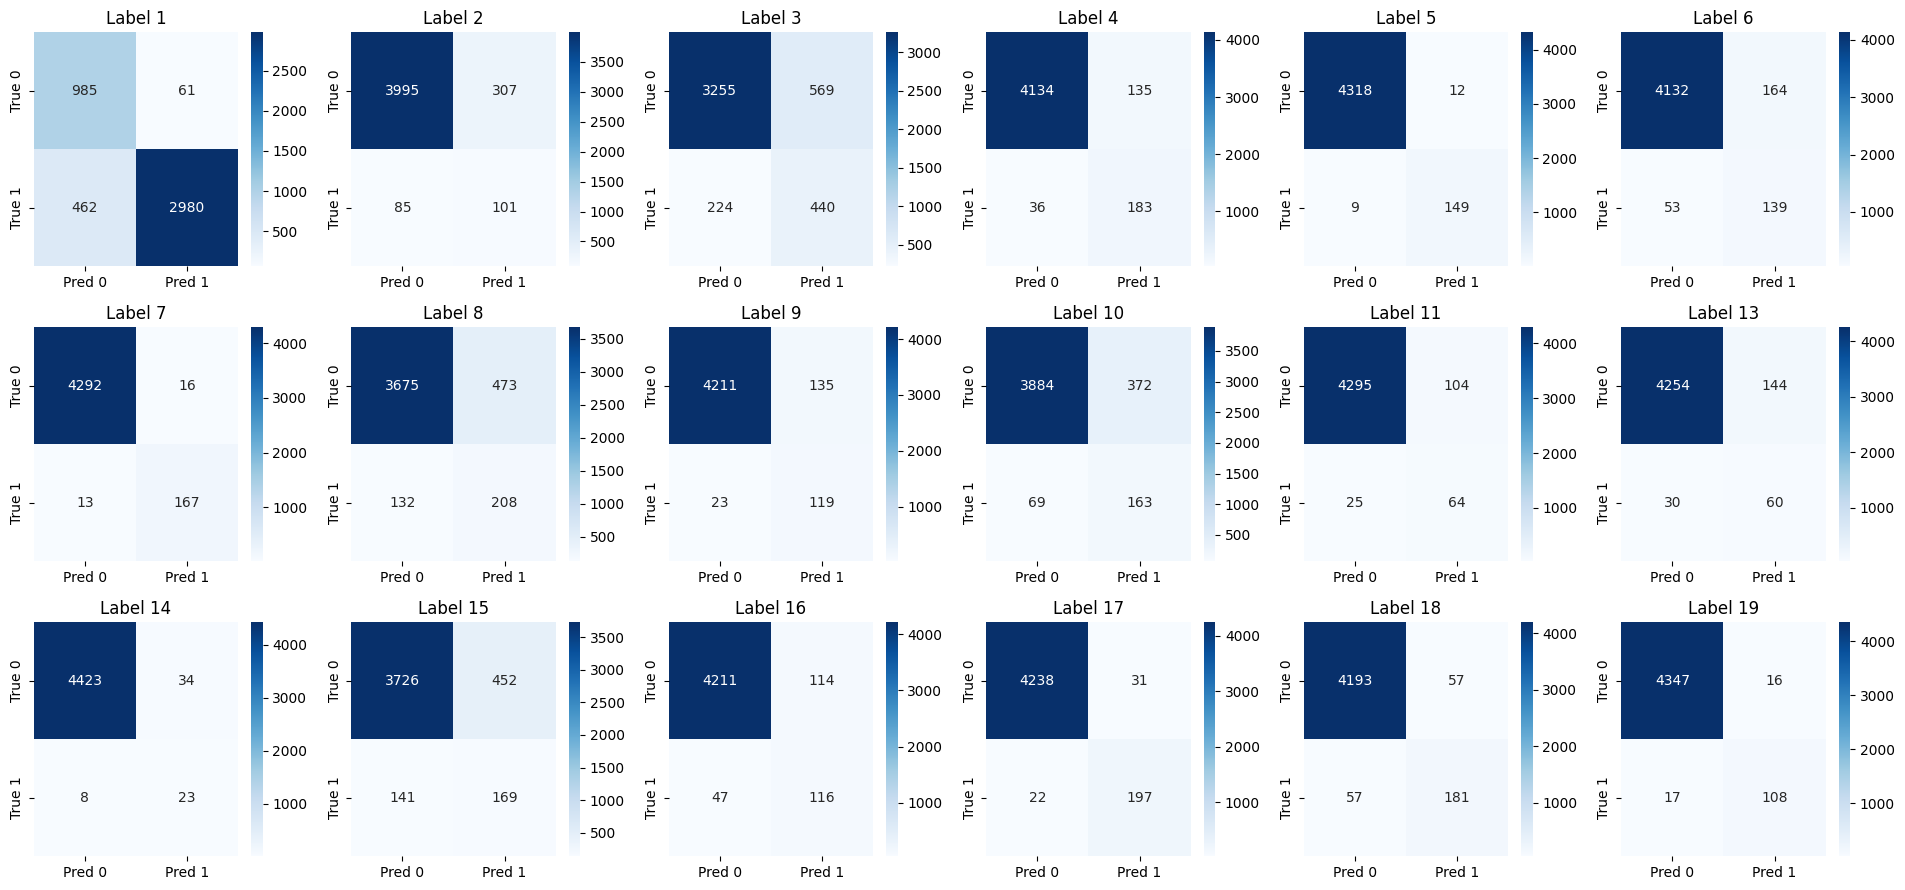

In [319]:
def plot_multilabel_confusion_matrices_text(y_true, y_pred, class_names, ncols=6):
    cms = multilabel_confusion_matrix(y_true, y_pred)

    n_classes = len(class_names)
    ncols = min(ncols, n_classes)
    nrows = int(np.ceil(n_classes / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.0 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, (matrix, class_name) in enumerate(zip(cms, class_names)):
        tn, fp, fn, tp = matrix.ravel()
        cm_display = np.array([[tn, fp], [fn, tp]])

        sns.heatmap(
            cm_display,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"],
            ax=axes[i],
        )
        axes[i].set_title(f"Label {class_name}")

    for ax in axes[n_classes:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_multilabel_confusion_matrices_text(
    y_test,
    best_text_pred,
    class_names=[str(label) for label in mlb.classes_],
    ncols=6,
)

### 6.5 Comparaison des resultats et selection du meilleur modele texte


## 7. Analyse et interpretation des resultats


### 7.1 Affichage de quelques predictions de test


### 7.2 Interpretation avec LimeTextExplainer


### 7.3 Analyse des erreurs


### 7.4 Sauvegarde du modele texte et pistes d'amelioration

Le modele retenu dans cette partie constitue la branche textuelle du systeme multimodal. Dans un pipeline complet, le modele, le tokenizer ou vectorizer, et les classes du `MultiLabelBinarizer` doivent etre sauvegardes afin d'etre recharges dans `multimodal_classifier.ipynb`.
